***<h1>Sentiment Analysis of Product Reviews on an E-commerce Website</h1>***

*__Problem statement__ -
With the rapid growth of e-commerce platforms, thousands of customer reviews are generated daily. Manually analyzing these reviews to determine overall customer sentiment is time-consuming and inefficient. Businesses need an automated solution that can accurately classify reviews as positive, negative, or neutral to quickly understand customer feedback, identify product issues, and enhance customer satisfaction.*

*__dataset:__ https://www.kaggle.com/datasets/busraercan/amazon-review-csv*

***<h2>Phase 1: Importing required libraries and initial setup***

*This project uses Pandas and NumPy for data handling, and Matplotlib and Seaborn for visualization.
Text preprocessing is done using NLTK, Regex, and WordCloud for cleaning and visualizing text.
Machine learning tasks depend on Scikit-learn, which provides tools for feature extraction (TF-IDF), model building (Naive Bayes, Linear SVM), cross-validation, and performance evaluation.
Warnings is used to suppress unnecessary system messages.*

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [6]:
import re      
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('punkt_tab')

In [7]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from imblearn.over_sampling import SMOTE

In [8]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import classification_report

In [9]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="darkgrid")

***<h2>Phase 2: Loading and cleaning the dataset to work on***

In [11]:
review= pd.read_csv(r'amazon_review.csv')

print("\nFirst 5 rows of the dataset:")
review.head()


First 5 rows of the dataset:


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues with it.,4,Four Stars,1406073600,23-07-2014,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5,MOAR SPACE!!!,1382659200,25-10-2013,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4,nothing to really say....,1356220800,23-12-2012,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5,Great buy at this price!!! *** UPDATE,1384992000,21-11-2013,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5,best deal around,1373673600,13-07-2013,513,0,0


In [12]:
print("\nInformation about the dataset:\n")
review.info()


Information about the dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   reviewerID      4915 non-null   object
 1   asin            4915 non-null   object
 2   reviewerName    4914 non-null   object
 3   helpful         4915 non-null   object
 4   reviewText      4914 non-null   object
 5   overall         4915 non-null   int64 
 6   summary         4915 non-null   object
 7   unixReviewTime  4915 non-null   int64 
 8   reviewTime      4915 non-null   object
 9   day_diff        4915 non-null   int64 
 10  helpful_yes     4915 non-null   int64 
 11  total_vote      4915 non-null   int64 
dtypes: int64(5), object(7)
memory usage: 460.9+ KB


In [13]:
print('Count of rows and columns respectively:',review.shape)

Count of rows and columns respectively: (4915, 12)


In [14]:
df= review[['reviewText','overall']].copy()
print("\nIndependent dataframe of the important features:")
df.head()


Independent dataframe of the important features:


,reviewText,overall
0,No issues with it.,4
1,"Purchased this for my device, it worked as adv...",5
2,it works as expected. I should have sprung for...,4
3,This think has worked out great.Had a diff. br...,5
4,"Bought it with Retail Packaging, arrived legit...",5


In [15]:
df.dropna(subset=['reviewText'], inplace=True)

In [16]:
#mapping sentiments

def sentiment(rating):
    if rating <=2:
        return 'negative'
    elif rating ==3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['overall'].apply(sentiment)

print("\nDataframe after creating the target feature by mapping the sentiments:")
df.head()


Dataframe after creating the target feature by mapping the sentiments:


,reviewText,overall,sentiment
0,No issues with it.,4,positive
1,"Purchased this for my device, it worked as adv...",5,positive
2,it works as expected. I should have sprung for...,4,positive
3,This think has worked out great.Had a diff. br...,5,positive
4,"Bought it with Retail Packaging, arrived legit...",5,positive


*The below cell handles text preprocessing and cleaning. It converts all text to lowercase, removes URLs, removes non-alphabetic characters, and filters out stopwords to keep the meaningful words. Lemmatization is then applied to reduce words to their root forms. The cleaned summary and reviewText columns are combined into a single ‘reviews’ column for further analysis.*

In [18]:
stop_words = set(stopwords.words('english'))
l= WordNetLemmatizer()

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'http\S+', '', t)   # remove URLs
    t = re.sub(r'[^a-z\s]', '', t)  # keep only letters
    tokens = t.split()
    tokens = [l.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

df['reviews'] = (review['summary'].fillna('') + " " + df['reviewText'].fillna('')).apply(clean_text)
print('\nDataframe with combined reviews:')
df.head()


Dataframe with combined reviews:


,reviewText,overall,sentiment,reviews
0,No issues with it.,4,positive,four star issue
1,"Purchased this for my device, it worked as adv...",5,positive,moar space purchased device worked advertised ...
2,it works as expected. I should have sprung for...,4,positive,nothing really say work expected sprung higher...
3,This think has worked out great.Had a diff. br...,5,positive,great buy price update think worked greathad d...
4,"Bought it with Retail Packaging, arrived legit...",5,positive,best deal around bought retail packaging arriv...


***<h2>Phase 3 : Exploratory Data Analysis (EDA)***

*The dataset was analyzed to understand its structure and key patterns. Visualizations such as class/sentiment distribution were used to observe data imbalance, while the review length chart highlighted variation in text size among reviews. A dataframe of top frequent words revealed common terms used in the dataset, and word clouds for each sentiment label (positive, neutral, negative) visually represented the most dominant words within each class.*

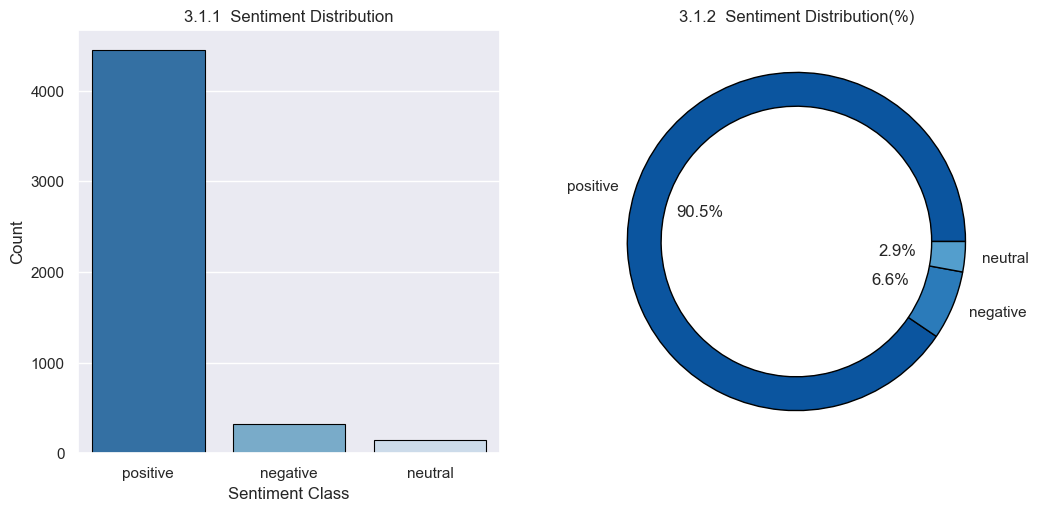

In [20]:
plt.figure(figsize=(12,5.5))
plt.subplot(1,2,1)
sns.barplot(df['sentiment'].value_counts(),palette='Blues_r',edgecolor='black',linewidth=0.8)
plt.title('3.1.1  Sentiment Distribution')
plt.ylabel('Count')
plt.xlabel('Sentiment Class')

plt.subplot(1,2,2)
plt.pie(df['sentiment'].value_counts(),labels=df['sentiment'].value_counts().index,autopct='%1.1f%%',
        colors=sns.color_palette('Blues_r'),
        wedgeprops={'linewidth': 1,'edgecolor': 'black','width': 0.2})
plt.title('3.1.2  Sentiment Distribution(%)')
plt.show()

*From the figures of 3.1 we get to identify the proportion of positive, negative, and neutral reviews. This helped reveal that the dataset was imbalanced, with positive reviews forming the majority, resulting in the need for resampling techniques in later phases.*

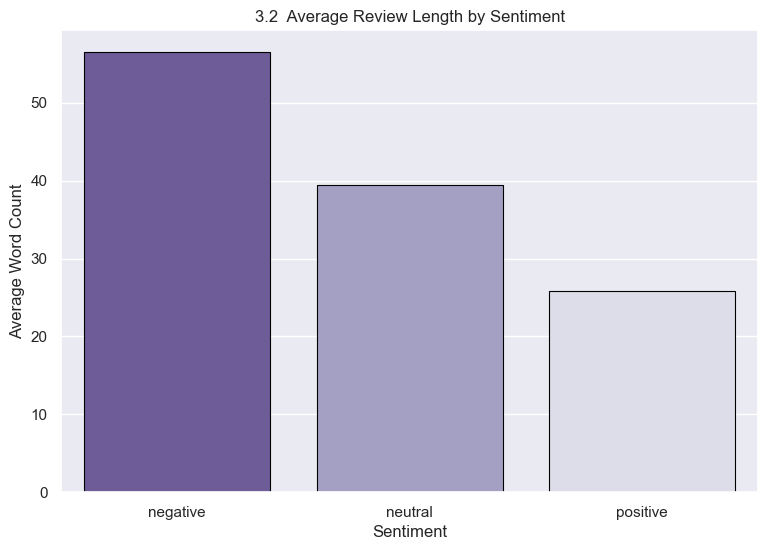

In [22]:
df['review_length'] = df['reviews'].apply(lambda x: len(x.split()))
plt.figure(figsize=(9,6))
sns.barplot(df.groupby('sentiment')['review_length'].mean(),
            palette='Purples_r',edgecolor='black',linewidth=0.8)

plt.title("3.2  Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Word Count")
plt.show()

*The figure 3.2 shows that negative reviews tend to be the longest, followed by neutral and then positive ones. This indicates that users expressing dissatisfaction often provide more detailed feedback, explaining the reasons for their negative experiences. On the other hand, positive reviews are generally shorter and more concise, limited to brief praise or satisfaction statements.*

In [24]:
from collections import Counter

def get_top_n_words(texts, n=20):
    words = ' '.join(texts).split()
    return Counter(words).most_common(n)

for sentiment in ['positive', 'neutral', 'negative']:
    top_words = get_top_n_words(df[df['sentiment']==sentiment]['reviews'])
    df_top = pd.DataFrame(top_words, columns=['Word', 'Frequency'])
    print(f"\nTop words in {sentiment} reviews:")
    display(df_top)


Top words in positive reviews:


,Word,Frequency
0,card,4944
1,work,2672
2,great,2504
3,gb,1715
4,phone,1676
5,memory,1585
6,sandisk,1223
7,good,1223
8,sd,1200
9,fast,1185



Top words in neutral reviews:


,Word,Frequency
0,card,288
1,phone,90
2,gb,87
3,work,86
4,sandisk,75
5,one,57
6,speed,52
7,sd,42
8,galaxy,41
9,would,39



Top words in negative reviews:


,Word,Frequency
0,card,1005
1,sandisk,276
2,phone,275
3,gb,219
4,month,188
5,one,149
6,problem,145
7,would,134
8,work,129
9,sd,128


*The most frequent words across sentiments highlight common product-related terms like “card,” “phone,” “gb,” and “sandisk.” Positive reviews emphasize words such as “great,” “good,” and “fast,” reflecting satisfaction with product performance. Neutral reviews focus on general product mentions without emotional tone, while negative reviews include terms like “problem,” “month,” and “format,” indicating issues. This distribution shows how sentiment influences word choice and review focus.*

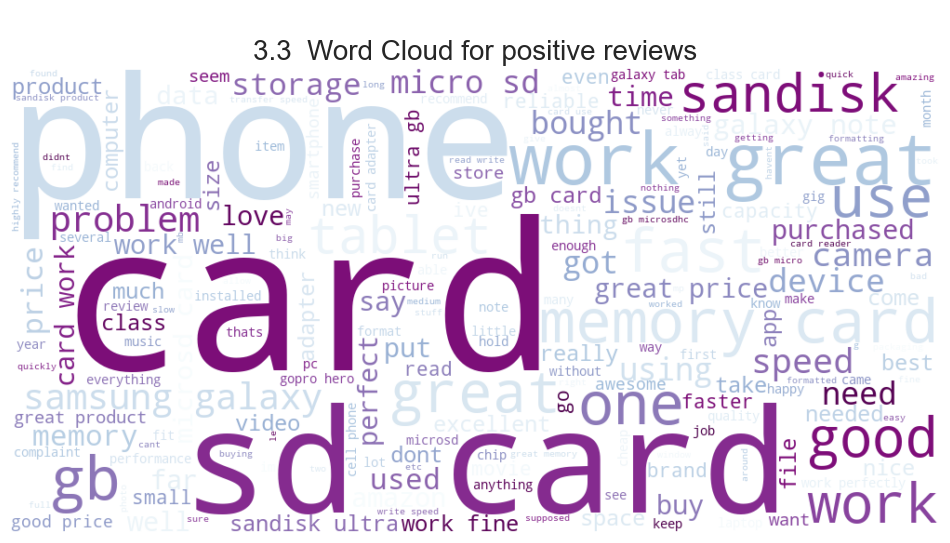

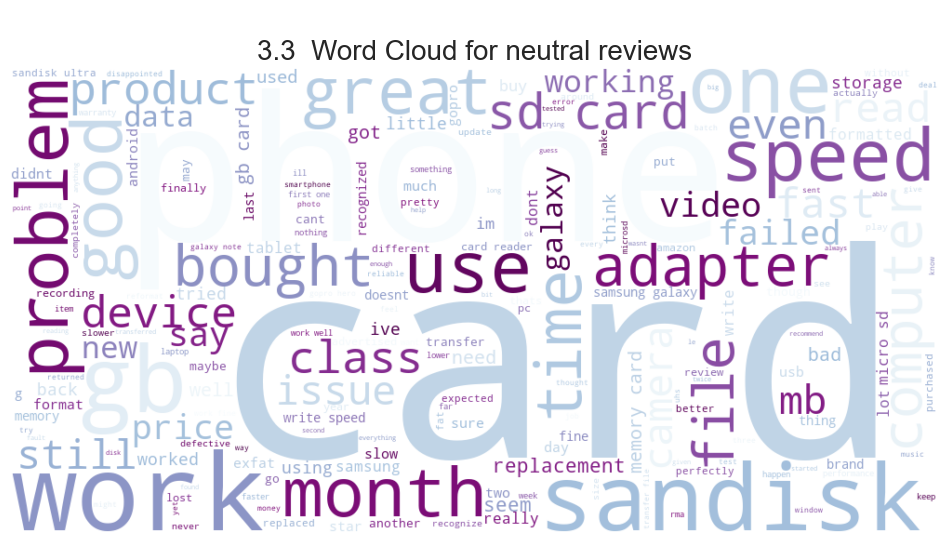

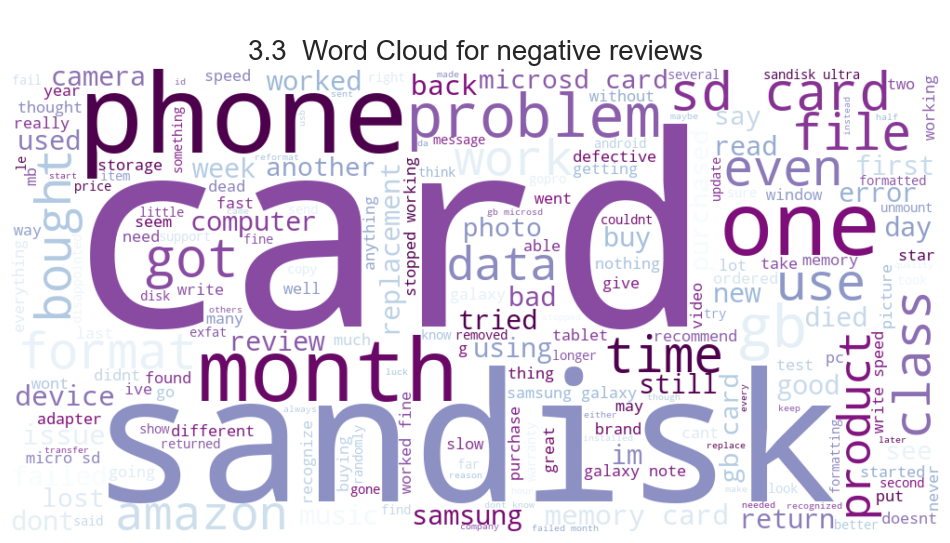

In [26]:
for sentiment in ['positive', 'neutral', 'negative']:
    
    text = ' '.join(df[df['sentiment']==sentiment]['reviews'])
    wc = WordCloud(width=1000, height=500, background_color='white', colormap='BuPu').generate(text)
    
    plt.figure(figsize=(12,8))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'\n3.3  Word Cloud for {sentiment} reviews',fontsize=20)
    plt.show()


*The word clouds in figure 3.3 reveal that discussions across all sentiments focus mainly on memory cards and performance, with frequent words like 'card', 'phone', 'sandisk', and 'sd'. Positive reviews highlight satisfaction through words such as 'great', 'fast', and 'good', reflecting reliability and efficiency. Neutral reviews use balanced, factual terms like 'use' and 'price', indicating average experiences. Negative reviews emphasize issues with words like 'problem', 'failed', 'error', and 'format', showing dissatisfaction. Overall, the tone and vocabulary shift clearly with sentiment intensity.*

***<h2>Phase 4 : Data Splitting and Feature Extraction***

*The dataset is divided into training and testing sets before vectorising to prevent data leakage, and text data is transformed into numerical form using TF-IDF which converts words into weighted numerical features based on their importance across documents.*

In [29]:
X= df['reviews']
y= df[['sentiment']]

X_train,X_test,y_train,y_test= train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [30]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english',ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train.astype(str).fillna(''))
X_test_tfidf = tfidf.transform(X_test.astype(str).fillna(''))

***<h2>Phase 5 : Data Balancing with SMOTE***

*SMOTE (Synthetic Minority Over-sampling Technique) is used to balance the dataset by creating synthetic samples for minority classes like Neutral and negative. This ensures the model doesn’t become biased toward the majority class i.e. Positive class that dominates as shown in the figure 3.1, improving classification performance on underrepresented labels.*

In [33]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_tfidf, y_train)
print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_res.value_counts())


Before SMOTE: sentiment
positive     3558
negative      259
neutral       114
Name: count, dtype: int64

After SMOTE: sentiment
negative     3558
neutral      3558
positive     3558
Name: count, dtype: int64


***<h2>Phase 6 : Model Training***

*This phase evaluates and compares model performance before and after applying SMOTE. Both Multinomial NB and Linear SVC are trained on the original i.e imbalanced and resampled i.e. balanced datasets. Metric reports are generated to observe how balancing the data affects prediction performance.*

*<h3>Multinomial Naive Bayes without SMOTE*

In [36]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb_before = nb.predict(X_test_tfidf)

print("Naive Bayes BEFORE SMOTE:\n")
print("Accuracy:", accuracy_score(y_test, y_pred_nb_before))
print('\nClassification Report:\n', classification_report(y_test, y_pred_nb_before))

Naive Bayes BEFORE SMOTE:

Accuracy: 0.9064089521871821

Classification Report:
               precision    recall  f1-score   support

    negative       0.50      0.02      0.03        65
     neutral       0.00      0.00      0.00        28
    positive       0.91      1.00      0.95       890

    accuracy                           0.91       983
   macro avg       0.47      0.34      0.33       983
weighted avg       0.85      0.91      0.86       983



*<h3> Linear Support Vector Machine without SMOTE*

In [38]:
svm = LinearSVC(C=1, random_state=42)
svm.fit(X_train_tfidf, y_train)
y_pred_svm_before = svm.predict(X_test_tfidf)

print("Support Vector Machine BEFORE SMOTE:\n")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_before))
print('\nClassification Report:\n',classification_report(y_test, y_pred_svm_before))

Support Vector Machine BEFORE SMOTE:

Accuracy: 0.9359104781281791

Classification Report:
               precision    recall  f1-score   support

    negative       0.74      0.54      0.62        65
     neutral       0.00      0.00      0.00        28
    positive       0.95      0.99      0.97       890

    accuracy                           0.94       983
   macro avg       0.56      0.51      0.53       983
weighted avg       0.91      0.94      0.92       983



***<h2> Phase 7: Cross Validation and hyperparameter tuning***

*StratifiedKFold is used to split the dataset into 5 folds, this technique maintains the class distribution ratio in each fold, shuffling it after each iteration so that every fold gets a turn to become the test set while the others are being trained on. This ensures that every fold is a good representative of the overall dataset.*

*GridSearchCV is used to find the best hyperparameters for a model by testing multiple parameter combinations through cross-validation. It ensures optimal model performance by selecting the parameter set that gives the highest evaluation score (e.g., F1-macro).*

*This phase uses GridSearchCV with Stratified K-Fold cross-validation to tune hyperparameters for both Naive Bayes and Linear SVM models. For NB, alpha (smoothing) is optimized, and for SVM, C (regularization strength) is tuned. The models are evaluated using F1-macro to handle class imbalance fairly. The best models from each search are then tested on unseen data, and their accuracy, confusion matrix, and classification report are generated for comparison.*

In [41]:
skf= StratifiedKFold(n_splits=5,shuffle=True, random_state=42)

*<h3>Multinomial Naive Bayes model training on balanced data with cross validation technique.*

In [43]:
param_nb={'alpha':[0.1,0.5,1.0]}

gs_nb= GridSearchCV(nb, param_nb, cv=skf, scoring='f1_macro',n_jobs=-1)
gs_nb.fit(X_train_res,y_train_res)

best_nb= gs_nb.best_estimator_
y_pred_nb= best_nb.predict(X_test_tfidf)

print('Best parameter:',gs_nb.best_params_)
print("\nAfter cross validation:\n")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print('F1-score:', f1_score(y_test, y_pred_nb, average='macro'))
print('\nClassification report:\n',classification_report(y_test, y_pred_nb))

Best parameter: {'alpha': 0.1}

After cross validation:

Accuracy: 0.9064089521871821
F1-score: 0.5379791945112129

Classification report:
               precision    recall  f1-score   support

    negative       0.52      0.75      0.62        65
     neutral       0.05      0.04      0.04        28
    positive       0.97      0.94      0.96       890

    accuracy                           0.91       983
   macro avg       0.51      0.58      0.54       983
weighted avg       0.91      0.91      0.91       983



*<h3>Linear Support Vector Machine model training on balanced data with cross validation technique.*

In [45]:
param_svm={'C':[0.01, 0.1, 1, 10]}

gs_svm= GridSearchCV(svm, param_svm, cv=skf, scoring='f1_macro',n_jobs=-1)
gs_svm.fit(X_train_res,y_train_res)

best_svm= gs_svm.best_estimator_
y_pred_svm= best_svm.predict(X_test_tfidf)

print('Best parameter:', gs_svm.best_params_)
print("\nAfter cross validation:\n")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print('F1-score:', f1_score(y_test, y_pred_svm, average='macro'))
print('\nClassification report:\n',classification_report(y_test, y_pred_svm))

Best parameter: {'C': 10}

After cross validation:

Accuracy: 0.9287894201424212
F1-score: 0.5280293269525739

Classification report:
               precision    recall  f1-score   support

    negative       0.67      0.57      0.62        65
     neutral       0.00      0.00      0.00        28
    positive       0.95      0.98      0.97       890

    accuracy                           0.93       983
   macro avg       0.54      0.52      0.53       983
weighted avg       0.91      0.93      0.92       983



***<h2> Phase 8: Model Evaluation and Comparison***

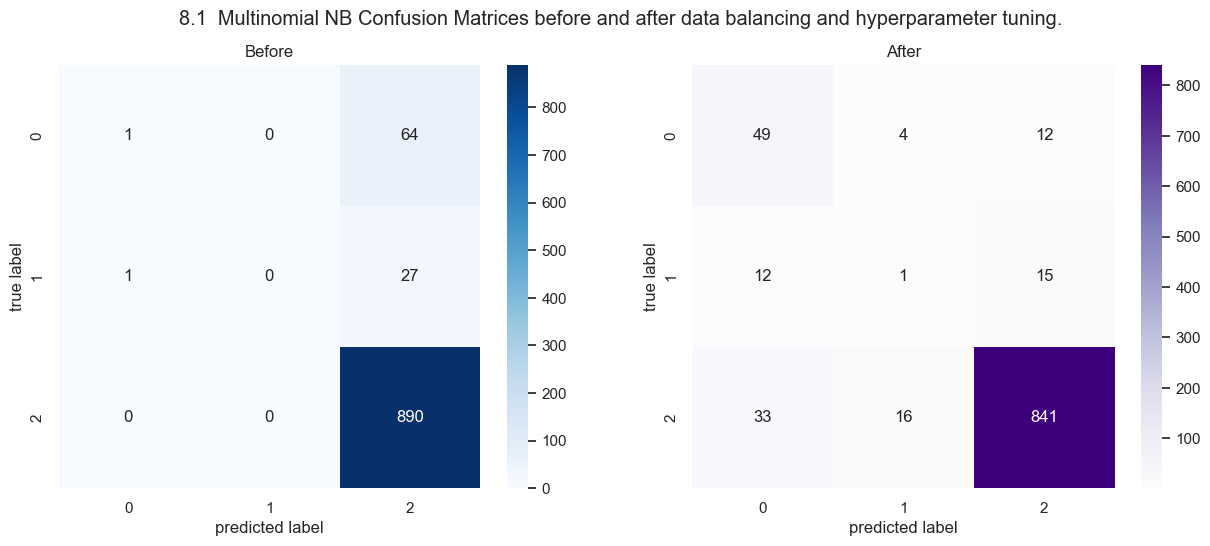

In [47]:
cm_nb_before= confusion_matrix(y_test, y_pred_nb_before)
cm_nb_after= confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize = (15,5.5))
plt.suptitle('8.1  Multinomial NB Confusion Matrices before and after data balancing and hyperparameter tuning.')

plt.subplot(1,2,1)
sns.heatmap(cm_nb_before, annot=True, cmap= 'Blues', fmt='d')
plt.title('Before')
plt.xlabel('predicted label')
plt.ylabel('true label')

plt.subplot(1,2,2)
sns.heatmap(cm_nb_after, annot= True, cmap= 'Purples', fmt='d')
plt.title('After')
plt.xlabel('predicted label')
plt.ylabel('true label')
plt.show()

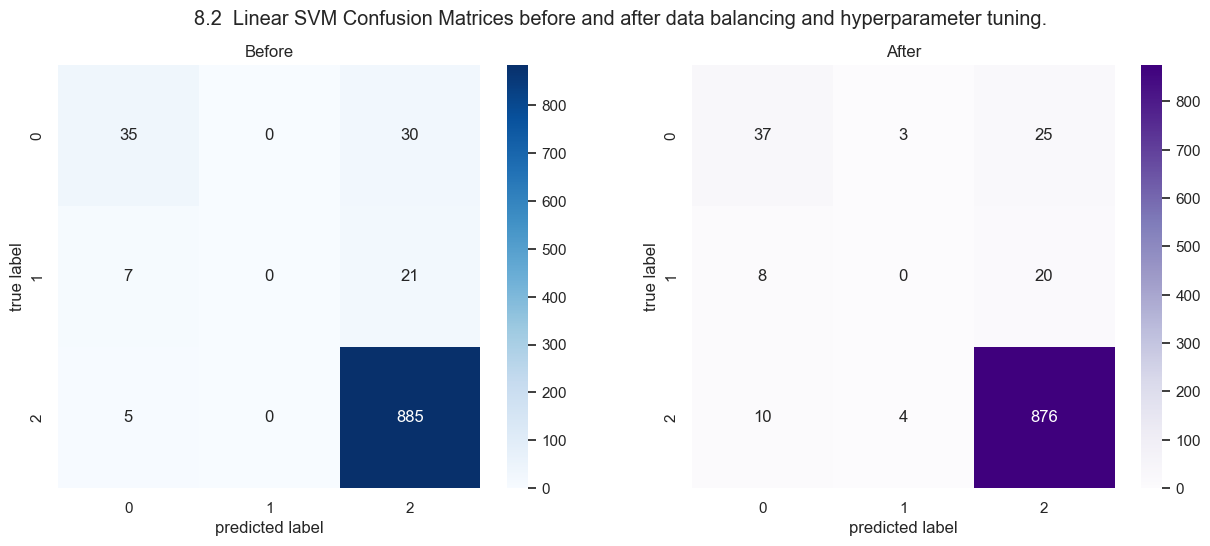

In [48]:
cm_svm_before= confusion_matrix(y_test, y_pred_svm_before)
cm_svm_after= confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize = (15,5.5))
plt.suptitle('8.2  Linear SVM Confusion Matrices before and after data balancing and hyperparameter tuning.')

plt.subplot(1,2,1)
sns.heatmap(cm_svm_before, annot=True, cmap= 'Blues', fmt='d')
plt.title('Before')
plt.xlabel('predicted label')
plt.ylabel('true label')

plt.subplot(1,2,2)
sns.heatmap(cm_svm_after, annot= True, cmap= 'Purples', fmt='d')
plt.title('After')
plt.xlabel('predicted label')
plt.ylabel('true label')
plt.show()

*As seen in figure 8.1 and 8.2 after applying SMOTE, the confusion matrix visuals show that the model’s predictions are more evenly distributed across all three sentiment classes. While accuracy may slightly decrease, this happens because the model no longer overfits to the majority (positive) class. Instead, it learns to recognize neutral and negative reviews more effectively. This trade-off improves recall and F1-score for minority classes, leading to a more balanced and fair sentiment classification performance.*

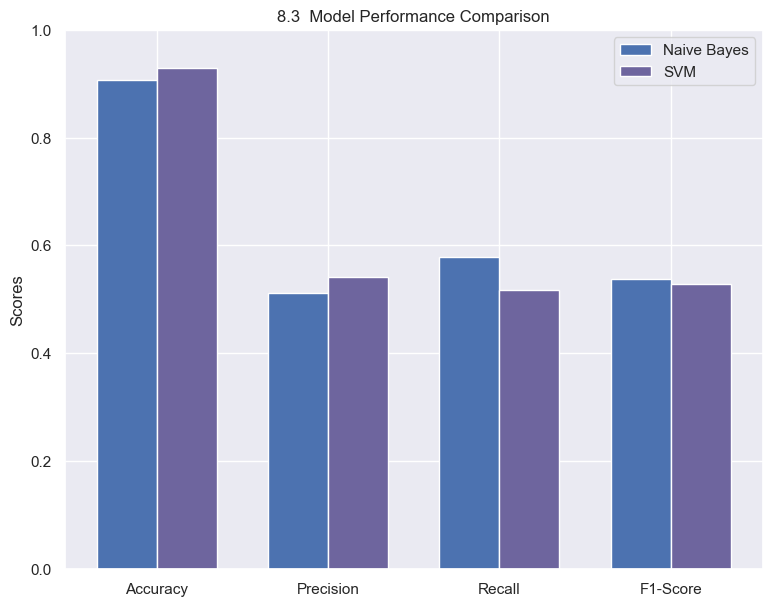

In [50]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

metrics_nb = [
    accuracy_score(y_test, y_pred_nb),
    precision_score(y_test, y_pred_nb, average='macro'),
    recall_score(y_test, y_pred_nb, average='macro'),
    f1_score(y_test, y_pred_nb, average='macro') 
]

metrics_svm = [
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm, average='macro'),
    recall_score(y_test, y_pred_svm, average='macro'),
    f1_score(y_test, y_pred_svm, average='macro') 
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9,7))
plt.bar(x - width/2, metrics_nb, width,label='Naive Bayes')
plt.bar(x + width/2, metrics_svm, width, label= 'SVM', color='#6e659e')

plt.ylabel('Scores')
plt.title('8.3  Model Performance Comparison')
plt.xticks(x,metrics)
plt.ylim(0, 1)
plt.legend()
plt.show()

*It is observed in the figure 8.3 that the SVM model slightly outperforms Naive Bayes in terms of overall accuracy and precision, indicating more reliable and consistent predictions. Although Naive Bayes shows marginally higher recall, SVM maintains a balanced performance across all metrics, making it the more suitable model for this sentiment analysis task. Therefore, SVM is selected as the final model due to its better generalization and predictive stability.*

***<h2> Summary:***

- *Linear SVM and Multinomial Naive Bayes (NB) were applied for sentiment classification on 4915 product reviews (imbalanced dataset: majority positive).*
- *SVM Results: Achieved 92.9% accuracy and F1-score of 0.53 after cross-validation. Best hyperparameter: C = 10. It performed well on the majority positive class with high precision (0.95) and recall (0.98), but struggled with the minority (neutral) class due to imbalance.*
- *Naive Bayes Results: Achieved 90.6% accuracy and F1-score of 0.54 with best hyperparameter α = 0.1. NB showed slightly better recall for the negative class but poorer results for the neutral class.*
- *Insights: Both models show strong overall accuracy but low macro average scores, indicating poor performance on minority classes (neutral, negative). SVM demonstrated better generalization and precision compared to NB.*
- *Final Model Chosen: SVM, due to its higher accuracy, robustness to high-dimensional data, and better handling of feature sparsity typical in text classification.*

***<h2> Classifying user's input***

In [97]:
def predict_sentiment(review, model, vectorizer):
    cleaned = clean_text(review)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return pred
    
reviews=   ['ok storage somewhat, would not but it again. '] #neu

for user_review in reviews:
    print(f'User review: "{user_review}"')
    print("\nPredicted Sentiment (Naive Bayes):", predict_sentiment(user_review, nb, tfidf))
    print("Predicted Sentiment (Linear SVM):", predict_sentiment(user_review, svm, tfidf))
    
    print("\nPredicted Sentiment (Naive Bayes with SMOTE and GridSearchCV):", predict_sentiment(user_review, best_nb, tfidf))
    print("Predicted Sentiment (Linear SVM with SMOTE and GridSearchCV):", predict_sentiment(user_review, best_svm, tfidf))
    print('-'*100)

User review: "ok storage somewhat, would not but it again. "

Predicted Sentiment (Naive Bayes): positive
Predicted Sentiment (Linear SVM): positive

Predicted Sentiment (Naive Bayes with SMOTE and GridSearchCV): neutral
Predicted Sentiment (Linear SVM with SMOTE and GridSearchCV): neutral
----------------------------------------------------------------------------------------------------
